# 21 — Rust controller bakeoff (no rollout)

Compare ladder controllers under **oracle shelf** (SIM-01=B) and **filtered**
beliefs (`session.act` on **P1** channels: arrivals + sales + waste totals).

| Arm | Oracle | Filtered (P1) |
| --- | --- | --- |
| `constant` | yes | yes |
| `rung0` | yes | no (`session.act` unsupported) |
| `sw` | yes | yes |
| `sla_pb` | yes | yes |

**Production budget:** `n_burn=2`, `n_score=45` → **47-day** horizon per shard.
Modal flat-spawn: oracle **40** shards + filtered **30** shards = **70** concurrent.
Per-arm ρ: `sw`=0.80 (damped_sw BO); `sla_pb`=0.50 (SOO BO).

Prior 14-day results archived under `archive_14d/` for horizon comparison.


In [1]:
from __future__ import annotations

import json
import os
import time
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (_candidate / "src" / "blueberries_voi").is_dir():
        REPO_ROOT = _candidate
        break

_wheel_dir = REPO_ROOT / "dist" / "wheel"
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)

from blueberries_voi.experiments.controller_bakeoff import (
    ARM_LABELS,
    BAKEOFF_ARMS,
    DEFAULT_CONTROLLER_SEEDS,
    FILTERED_ARMS,
    FILTERED_OBS_PRESET,
    PRODUCTION_N_SCORE,
    arms_for_belief_world,
    filtered_obs_channels,
    resolve_arm_alpha,
    resolve_arm_rho,
)
from blueberries_voi.experiments.modal_dispatch import run_batch
from blueberries_voi.experiments.policy_bakeoff_viz import (
    summarize_distribution_by_arm,
    write_alpha_vs_observed_figure,
    write_metric_boxplot_figure,
    write_paired_delta_boxplot_figure,
    write_paired_delta_figure,
    write_profit_bars_figure,
    write_runtime_bars_figure,
    write_runtime_frontier_figure,
    write_runtime_violin_figure,
    write_waste_stockout_bars_figure,
)
from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params

BATCH_MODE: Literal["modal", "local"] = "modal"
SMOKE = False
SEEDS = (42,) if SMOKE else DEFAULT_CONTROLLER_SEEDS
N_BURN, N_SCORE = 2, PRODUCTION_N_SCORE
DEFAULT_RHO = load_damped_sw_bo_params()[1]
OUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "nb21_controller_bakeoff"
ARCHIVE_14D = OUT_DIR / "archive_14d"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ARCHIVE_14D.mkdir(parents=True, exist_ok=True)

SHARED_ARMS = ("constant", "sw", "sla_pb")
ARM_RHOS = {arm: resolve_arm_rho(arm, default_rho=DEFAULT_RHO) for arm in SHARED_ARMS}
print(
    f"BATCH_MODE={BATCH_MODE} SMOKE={SMOKE} n_burn={N_BURN} n_score={N_SCORE} "
    f"horizon={N_BURN + N_SCORE} filtered_obs={FILTERED_OBS_PRESET} rhos={ARM_RHOS}"
)


BATCH_MODE=modal SMOKE=False n_burn=2 n_score=45 horizon=47 filtered_obs=P1 rhos={'constant': 0.8, 'sw': 0.8, 'sla_pb': 0.8}


## Modal bakeoff — oracle (40 shards, flat spawn)

Oracle SIM-01=B shelf; 10 seeds × 4 arms.


In [2]:
t0_oracle = time.perf_counter()
oracle_rows = run_batch(
    "controller_bakeoff",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=SEEDS,
    arms=BAKEOFF_ARMS,
    rho=DEFAULT_RHO,
    belief_world="oracle",
    n_burn=N_BURN,
    n_score=N_SCORE,
    out_path=OUT_DIR / "oracle_n45_rows.json",
)
oracle_wall_s = time.perf_counter() - t0_oracle
oracle_df = pd.DataFrame(oracle_rows)
print(f"Oracle Modal wall: {oracle_wall_s:.1f} s for {len(oracle_rows)} shards")
display(oracle_df.groupby("arm_id")[["rho", "profit", "fill_rate", "day_no_stockout_rate"]].agg(["median", "mean"]).round(2))


modal batch:   0%|          | 0/40 [00:00<?, ?shard/s]

[2026-08-28T07:28:31Z] modal batch collected 40 shards


Oracle Modal wall: 16.1 s for 40 shards


rho        profit          fill_rate       day_no_stockout_rate  \
         median mean   median     mean    median  mean               median   
arm_id                                                                        
constant    0.8  0.8  2108.25  2080.00      0.97  0.97                 0.98   
rung0       0.8  0.8  1746.75  1675.65      0.87  0.86                 0.78   
sla_pb      0.5  0.5  2135.50  2146.05      0.95  0.95                 0.91   
sw          0.8  0.8  1984.75  1977.00      0.91  0.91                 0.82   

                
          mean  
arm_id          
constant  0.97  
rung0     0.78  
sla_pb    0.90  
sw        0.82

## Modal bakeoff — filtered P1 (30 shards, flat spawn)

Filter posterior via `session.act`; P1 obs channels; 10 seeds × 3 arms.


In [3]:
t0_filtered = time.perf_counter()
filtered_rows = run_batch(
    "controller_bakeoff",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=SEEDS,
    arms=FILTERED_ARMS,
    rho=DEFAULT_RHO,
    belief_world="filtered",
    n_burn=N_BURN,
    n_score=N_SCORE,
    out_path=OUT_DIR / "filtered_p1_n45_rows.json",
)
filtered_wall_s = time.perf_counter() - t0_filtered
filtered_df = pd.DataFrame(filtered_rows)
print(f"Filtered Modal wall: {filtered_wall_s:.1f} s for {len(filtered_rows)} shards")
display(filtered_df.groupby("arm_id")[["rho", "profit", "fill_rate", "day_no_stockout_rate"]].agg(["median", "mean"]).round(2))

shard_rows = oracle_rows + filtered_rows
(OUT_DIR / "controller_bakeoff_rows.json").write_text(json.dumps(shard_rows, indent=2) + "\n")
bakeoff_summary = {
    "n_burn": N_BURN,
    "n_score": N_SCORE,
    "horizon_days": N_BURN + N_SCORE,
    "filtered_obs": FILTERED_OBS_PRESET,
    "arm_rhos": ARM_RHOS,
    "oracle_modal_wall_s": oracle_wall_s,
    "filtered_modal_wall_s": filtered_wall_s,
    "oracle_shards": len(oracle_rows),
    "filtered_shards": len(filtered_rows),
}
(OUT_DIR / "bakeoff_summary.json").write_text(json.dumps(bakeoff_summary, indent=2) + "\n")


modal batch:   0%|          | 0/30 [00:00<?, ?shard/s]

[2026-08-28T07:28:49Z] modal batch collected 30 shards


Filtered Modal wall: 15.7 s for 30 shards


rho        profit          fill_rate       day_no_stockout_rate  \
         median mean   median     mean    median  mean               median   
arm_id                                                                        
constant    0.8  0.8  1639.00  1638.25      0.99  0.98                 0.98   
sla_pb      0.5  0.5  1695.75  1642.85      0.92  0.91                 0.86   
sw          0.8  0.8  1730.25  1748.10      0.90  0.90                 0.77   

                
          mean  
arm_id          
constant  0.98  
sla_pb    0.84  
sw        0.78

295

## Per-seed tables + distribution summaries (45-day)


In [4]:
df = pd.DataFrame(shard_rows)
for world, sub in df.groupby("belief_world"):
    arms = list(BAKEOFF_ARMS if world == "oracle" else FILTERED_ARMS)
    print(f"=== {world} ===")
    per_seed = sub.sort_values(["arm_id", "seed"])[
        ["seed", "arm_id", "alpha", "rho", "profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]
    ]
    display(per_seed.round(2).head(12))
    per_seed.to_csv(OUT_DIR / f"per_seed_{world}_n45.csv", index=False)

metrics = ["profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]
for world in ("oracle", "filtered"):
    world_rows = [r for r in shard_rows if r.get("belief_world") == world]
    arms = list(BAKEOFF_ARMS if world == "oracle" else FILTERED_ARMS)
    for metric in metrics:
        tbl = summarize_distribution_by_arm(world_rows, metric, arms=arms)
        tbl.to_csv(OUT_DIR / f"summary_{world}_{metric}_n45.csv")
        if metric == "profit":
            print(f"{world} profit summary:")
            display(tbl.round(2))


=== filtered ===


,seed,arm_id,alpha,rho,profit,waste,stockout,fill_rate,day_no_stockout_rate,elapsed_s
40,7,constant,0.50,0.8,1577.5,447,14,0.99,0.98,1.30
41,11,constant,0.50,0.8,1337.5,507,18,0.98,0.98,1.40
42,23,constant,0.50,0.8,1609.5,431,16,0.99,0.98,1.34
43,37,constant,0.50,0.8,1663.5,431,6,0.99,0.98,1.32
44,42,constant,0.50,0.8,1564.5,439,17,0.99,0.98,1.77
45,53,constant,0.50,0.8,1614.5,429,34,0.97,0.98,1.48
46,71,constant,0.50,0.8,1727.5,401,17,0.99,0.98,1.76
47,89,constant,0.50,0.8,1822.5,403,7,0.99,0.98,1.21
48,101,constant,0.50,0.8,1775.0,382,24,0.98,0.98,1.22
49,2024,constant,0.50,0.8,1690.5,415,29,0.98,0.98,1.32


=== oracle ===


,seed,arm_id,alpha,rho,profit,waste,stockout,fill_rate,day_no_stockout_rate,elapsed_s
0,7,constant,0.50,0.8,2184.5,275,31,0.98,0.98,0.03
1,11,constant,0.50,0.8,1980.5,317,52,0.96,0.98,0.03
2,23,constant,0.50,0.8,2053.5,289,45,0.97,0.98,0.03
3,37,constant,0.50,0.8,2273.5,239,24,0.98,0.98,0.03
4,42,constant,0.50,0.8,2154.0,270,39,0.97,0.96,0.03
5,53,constant,0.50,0.8,2062.5,295,39,0.97,0.96,0.03
6,71,constant,0.50,0.8,2176.0,280,26,0.98,0.98,0.03
7,89,constant,0.50,0.8,1773.5,395,22,0.98,0.98,0.03
8,101,constant,0.50,0.8,1907.5,345,29,0.98,0.98,0.03
9,2024,constant,0.50,0.8,2234.5,243,39,0.97,0.98,0.03


oracle profit summary:


,arm_id,median,q25,q75,min,max,mean,n
0,constant,2108.25,1998.75,2182.38,1773.5,2273.5,2080.00,10
1,rung0,1746.75,1626.00,1780.38,1246.0,1831.0,1675.65,10
2,sw,1984.75,1921.50,2033.88,1821.5,2091.0,1977.00,10
3,sla_pb,2135.50,2112.38,2227.88,1950.5,2328.5,2146.05,10


filtered profit summary:


,arm_id,median,q25,q75,min,max,mean,n
0,constant,1639.00,1585.50,1718.25,1337.5,1822.5,1638.25,10
1,sw,1730.25,1695.75,1823.12,1607.0,1850.5,1748.10,10
2,sla_pb,1695.75,1531.50,1771.75,1200.5,1929.5,1642.85,10


## Distribution figures (45-day)


In [5]:
oracle_only = [r for r in shard_rows if r.get("belief_world") == "oracle"]
filtered_only = [r for r in shard_rows if r.get("belief_world") == "filtered"]
write_profit_bars_figure(OUT_DIR / "01_profit_by_arm_oracle_n45.png", oracle_only, title="Oracle: mean profit (45 scored days)")
write_profit_bars_figure(OUT_DIR / "01b_profit_by_arm_filtered_n45.png", filtered_only, title=f"Filtered {FILTERED_OBS_PRESET}: mean profit (45 days)")
write_metric_boxplot_figure(OUT_DIR / "06_profit_boxplot_oracle_n45.png", oracle_only, "profit", ylabel="Profit ($)", title="Oracle profit distribution", arms=list(BAKEOFF_ARMS))
write_metric_boxplot_figure(OUT_DIR / "06b_profit_boxplot_filtered_n45.png", filtered_only, "profit", ylabel="Profit ($)", title="Filtered profit distribution", arms=list(FILTERED_ARMS))
write_waste_stockout_bars_figure(OUT_DIR / "02_waste_stockout_oracle_n45.png", oracle_only)
write_waste_stockout_bars_figure(OUT_DIR / "02b_waste_stockout_filtered_n45.png", filtered_only)
write_runtime_bars_figure(OUT_DIR / "03_runtime_by_arm_n45.png", shard_rows)
write_runtime_violin_figure(OUT_DIR / "08_runtime_violin_n45.png", shard_rows)
write_paired_delta_figure(OUT_DIR / "04_paired_delta_oracle_vs_sw_n45.png", oracle_only, baseline="sw")
write_paired_delta_figure(OUT_DIR / "04b_paired_delta_filtered_vs_sw_n45.png", filtered_only, baseline="sw", title="Filtered: profit delta vs sw")
write_paired_delta_boxplot_figure(OUT_DIR / "09_paired_delta_boxplot_oracle_n45.png", oracle_only, "profit", baseline="sw")
write_metric_boxplot_figure(OUT_DIR / "10_fill_rate_oracle_n45.png", oracle_only, "fill_rate", ylabel="Fill rate", title="Oracle fill rate", arms=list(BAKEOFF_ARMS))
write_metric_boxplot_figure(OUT_DIR / "10b_fill_rate_filtered_n45.png", filtered_only, "fill_rate", ylabel="Fill rate", title="Filtered fill rate", arms=list(FILTERED_ARMS))
write_metric_boxplot_figure(OUT_DIR / "11_day_no_stockout_oracle_n45.png", oracle_only, "day_no_stockout_rate", ylabel="Day no-stockout rate", title="Oracle day service", arms=list(BAKEOFF_ARMS))
write_alpha_vs_observed_figure(OUT_DIR / "12_alpha_vs_fill_rate_n45.png", oracle_only, observed_field="fill_rate")
write_alpha_vs_observed_figure(OUT_DIR / "13_alpha_vs_day_no_stockout_n45.png", oracle_only, observed_field="day_no_stockout_rate", title="Tuned α vs observed day no-stockout rate")
print(f"Wrote figures under {OUT_DIR}")


Wrote figures under /home/oliver/blog/blueberries-voi/.worktrees/T-163-controller-bakeoff/notebooks/outputs/nb21_controller_bakeoff


## Results summary (45 scored days, `n_burn=2`, horizon=47)

**Modal wall times:** oracle and filtered runs logged in `bakeoff_summary.json`.

### Oracle ranking (median profit, 45-day)

See executed output above; compare to 14-day archive.

### Filtered P1 ranking (median profit, 45-day)

Under filter posterior, adaptive controllers may reorder vs oracle.

### 45-day vs 14-day horizon

Prior runs archived in `archive_14d/`. Comparison table in next cell.


01_profit_by_arm.png


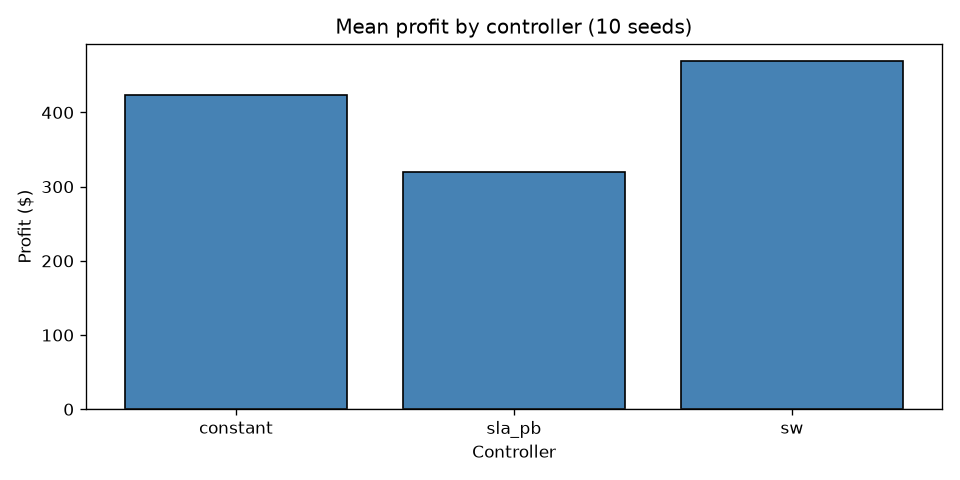

01_profit_by_arm_oracle_n45.png


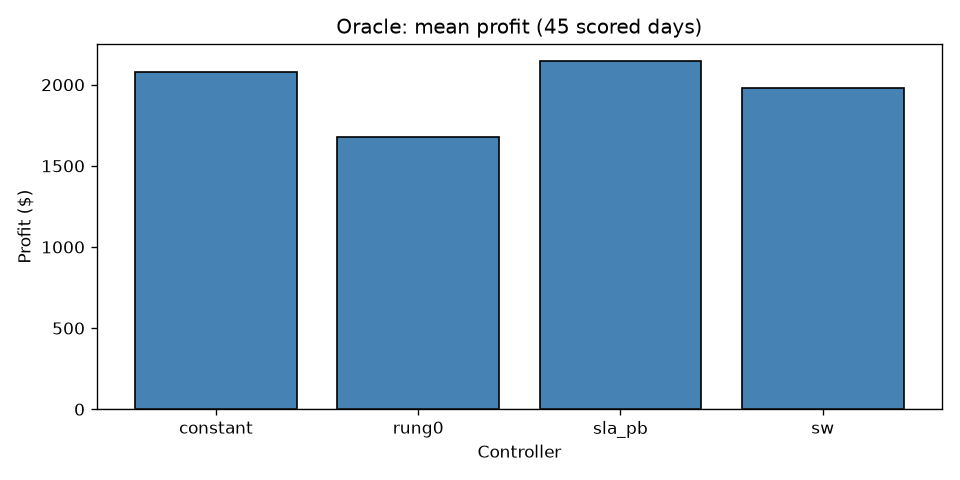

01b_profit_by_arm_filtered_n45.png


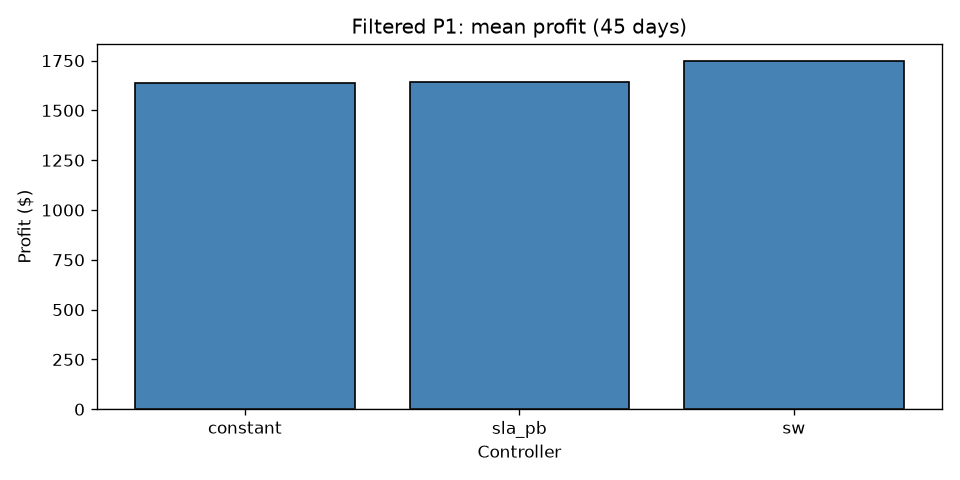

02_waste_stockout.png


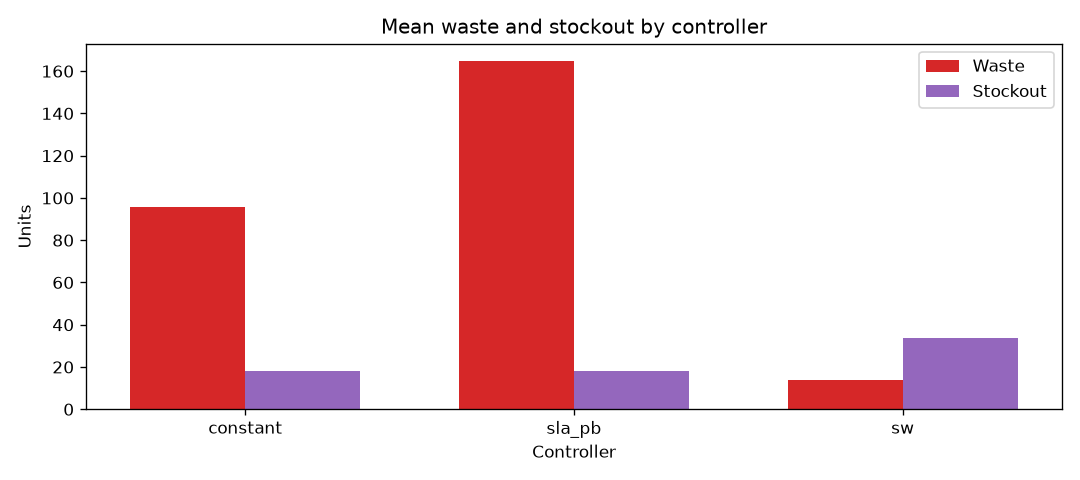

02_waste_stockout_oracle_n45.png


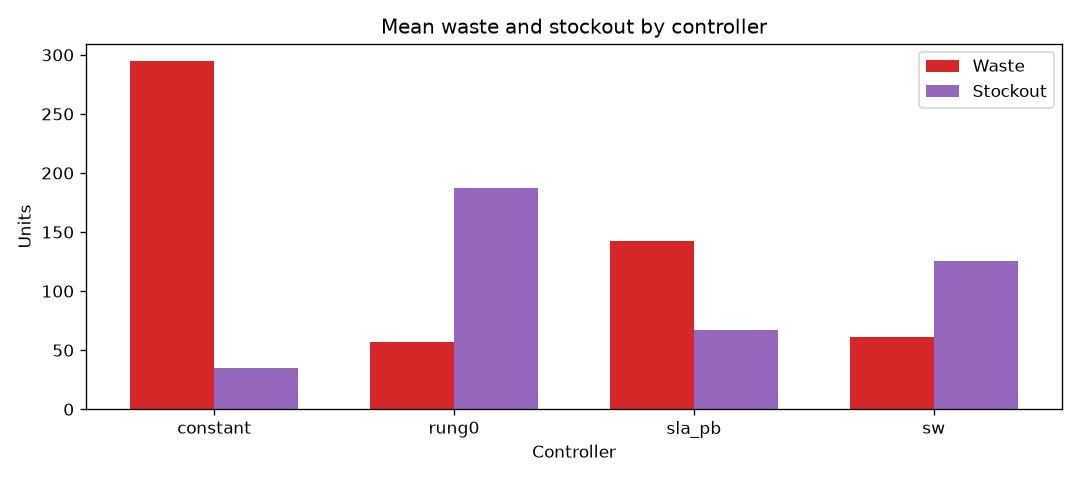

02b_waste_stockout_filtered_n45.png


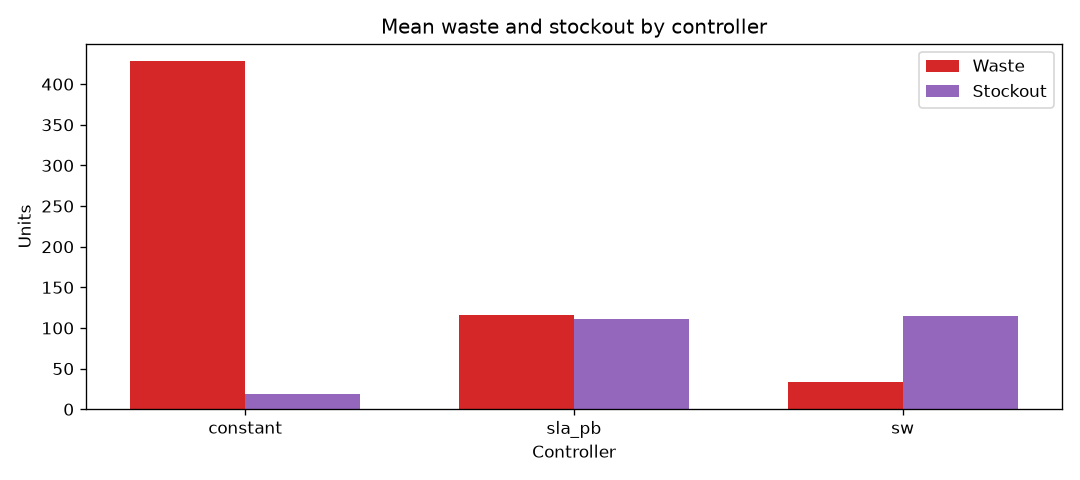

03_runtime_by_arm.png


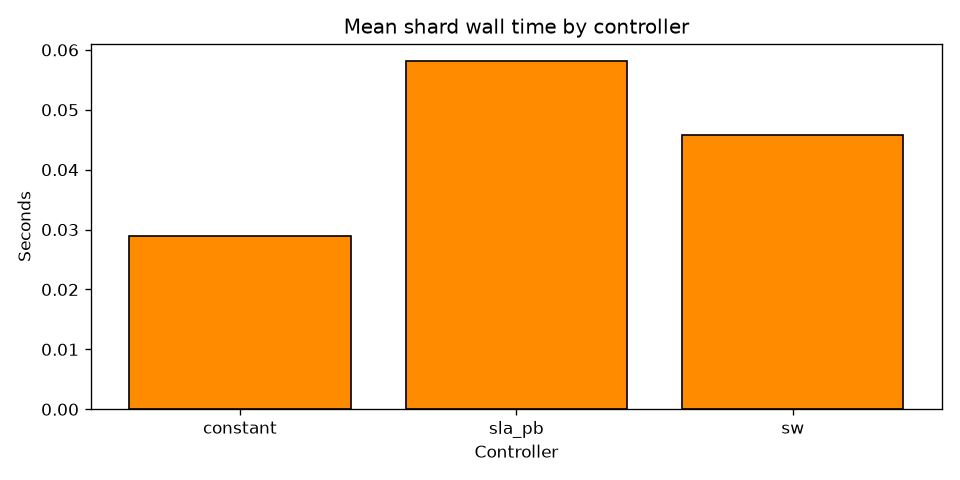

03_runtime_by_arm_n45.png


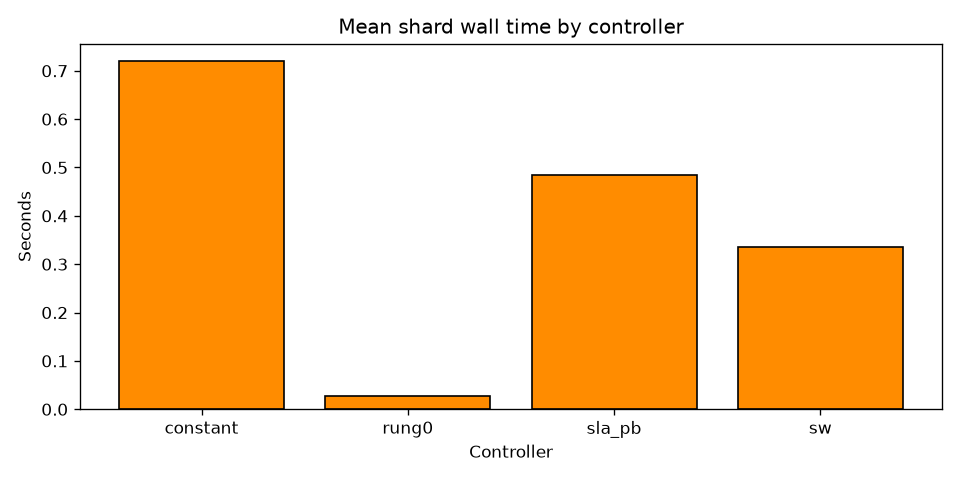

04_paired_delta_oracle_vs_sw_n45.png


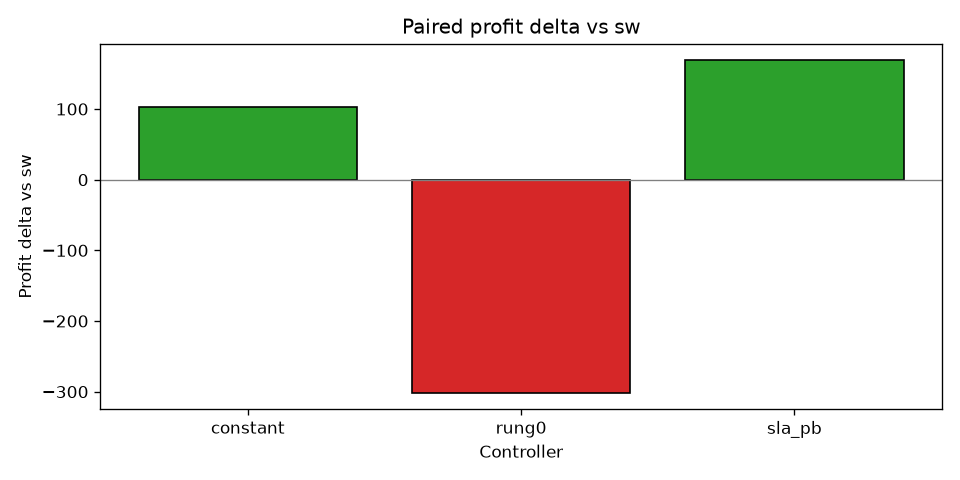

04_paired_delta_vs_sw.png


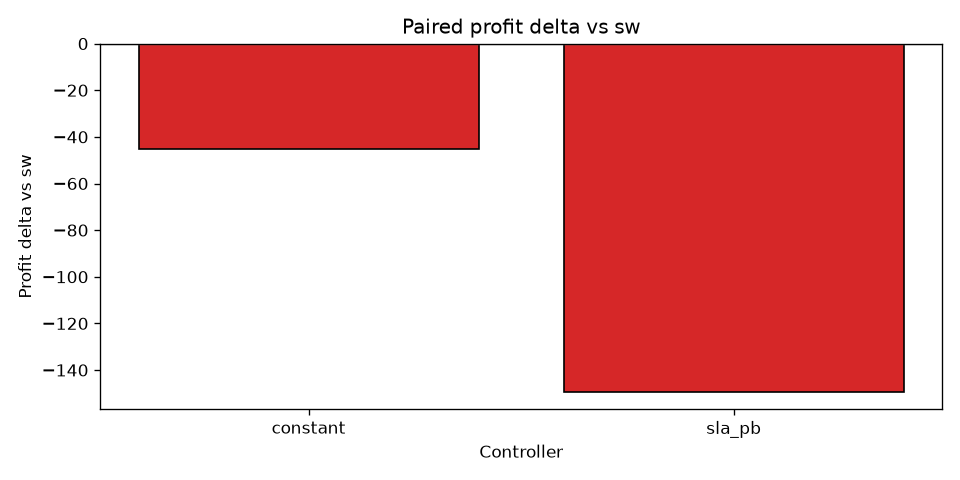

04b_paired_delta_filtered_vs_sw_n45.png


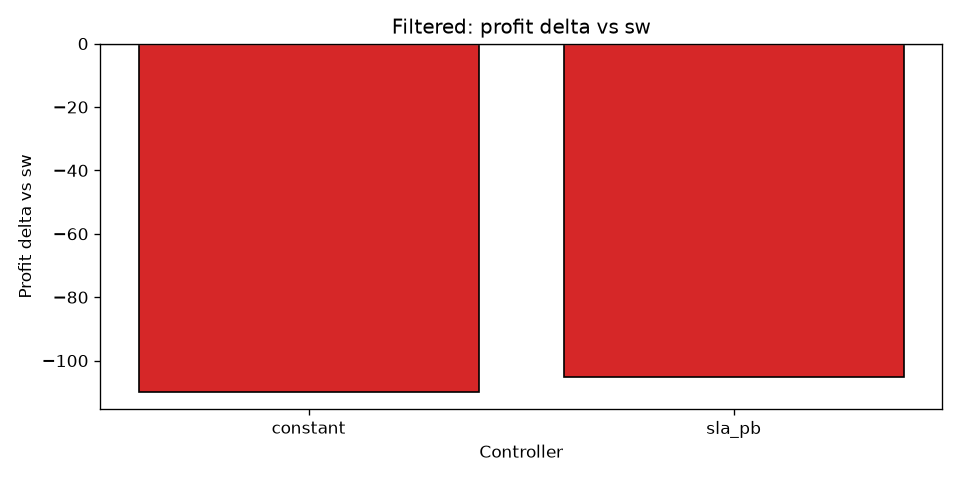

05_runtime_frontier.png


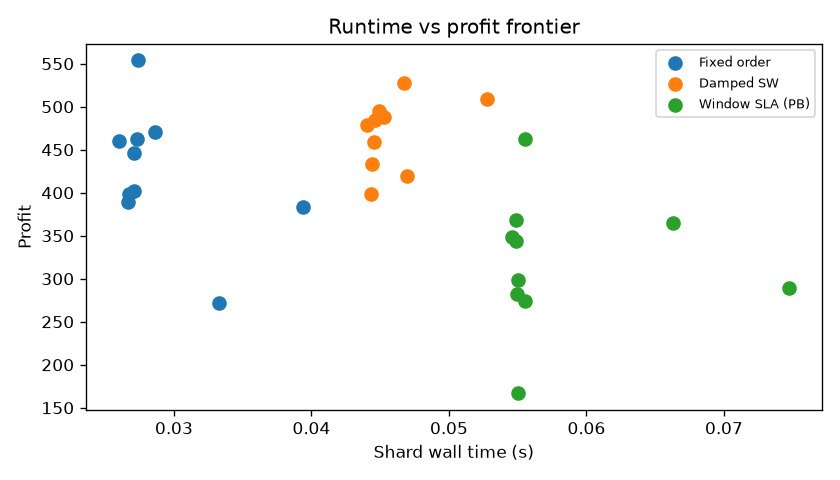

06_profit_boxplot.png


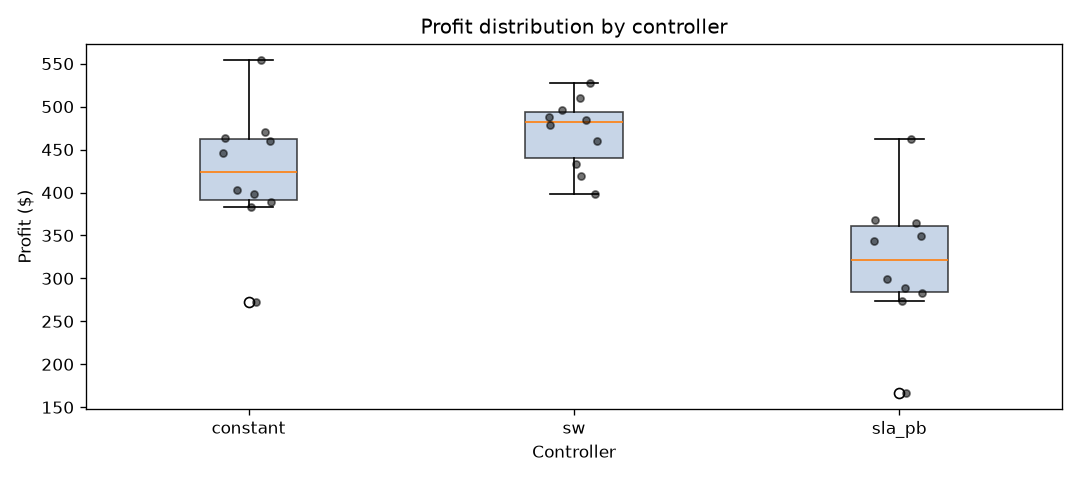

06_profit_boxplot_oracle_n45.png


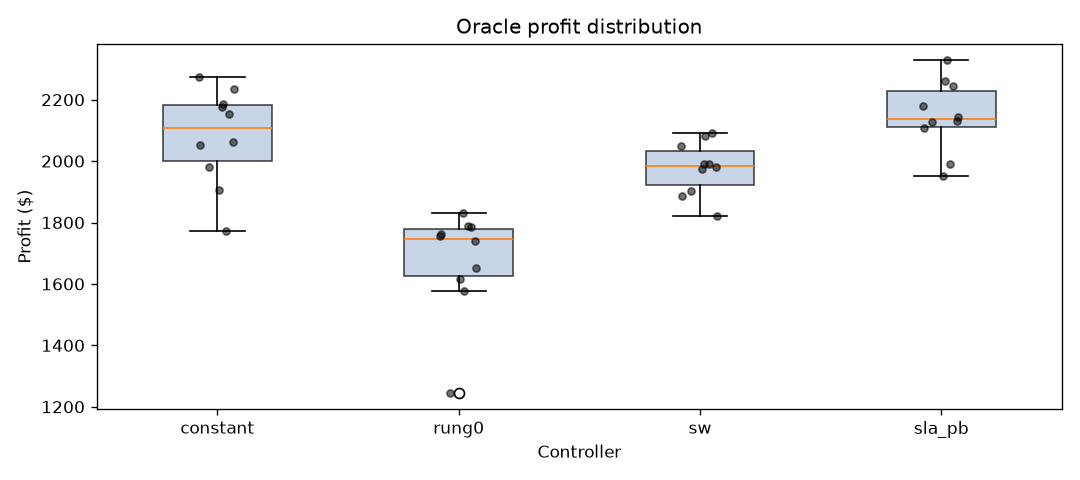

06b_profit_boxplot_filtered_n45.png


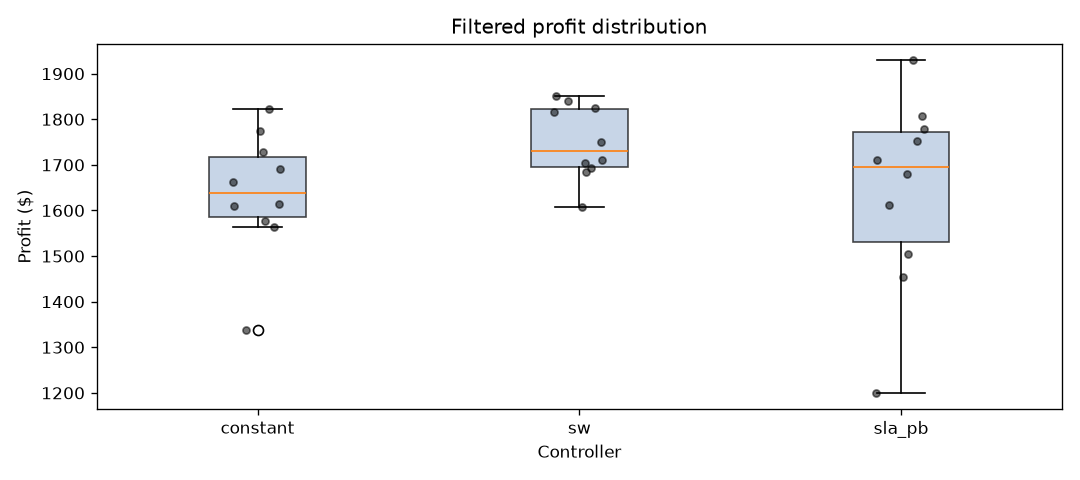

07_stockout_boxplot.png


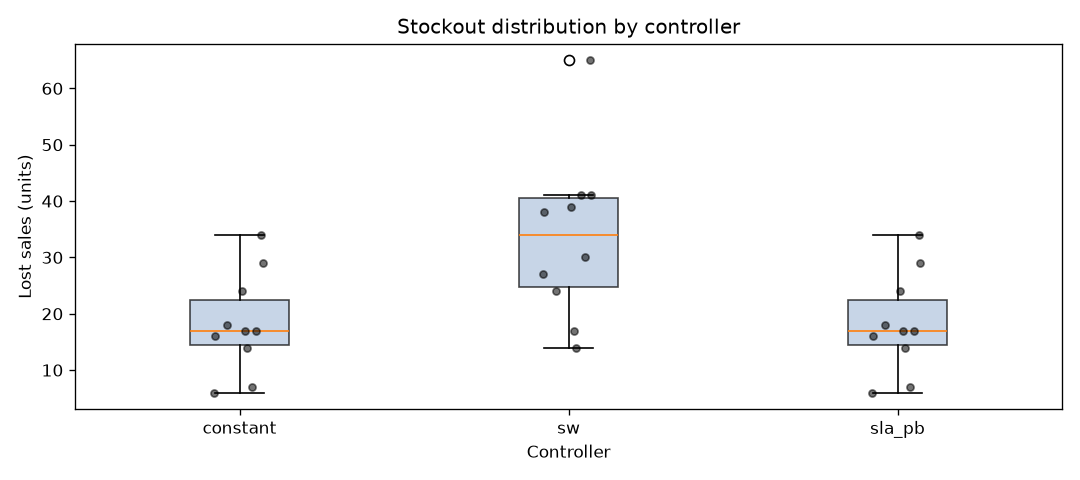

08_runtime_violin.png


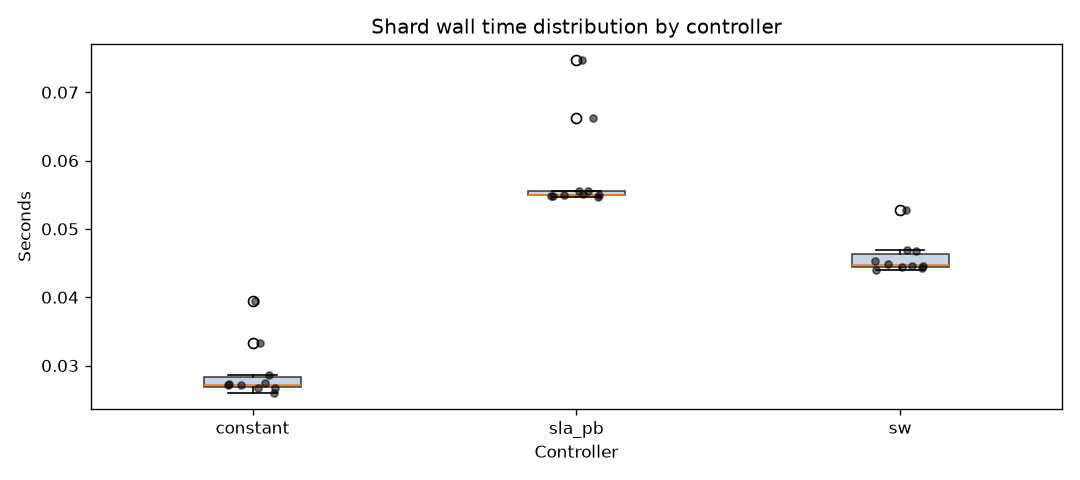

08_runtime_violin_n45.png


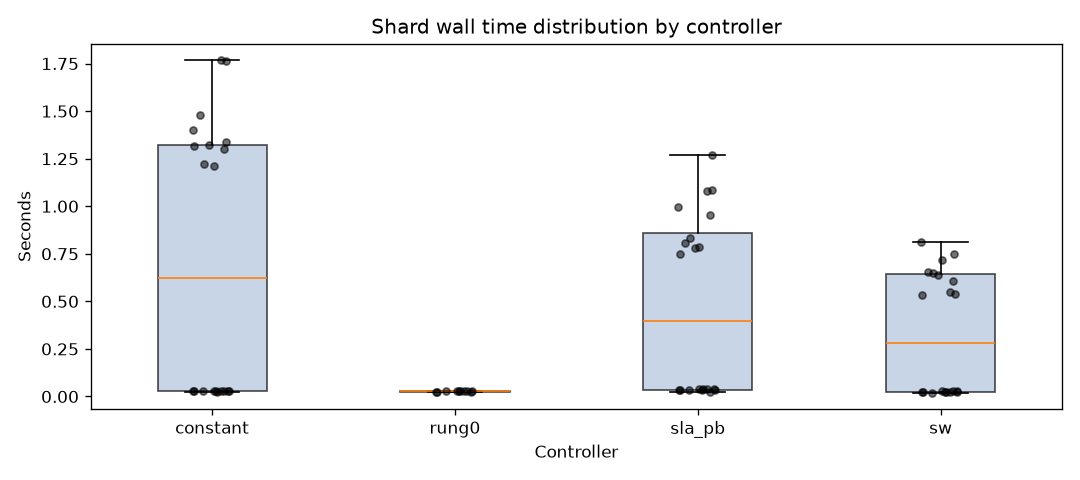

09_paired_delta_boxplot_oracle_n45.png


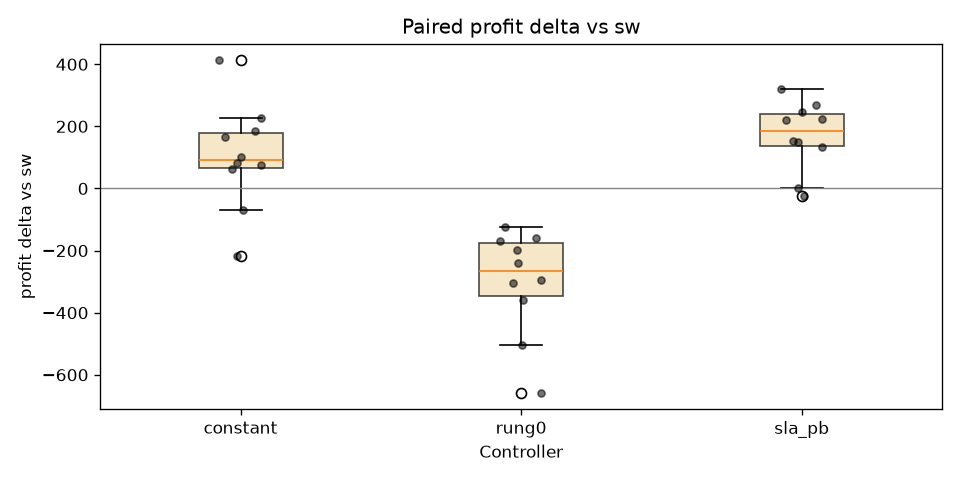

09_paired_delta_boxplot_vs_sw.png


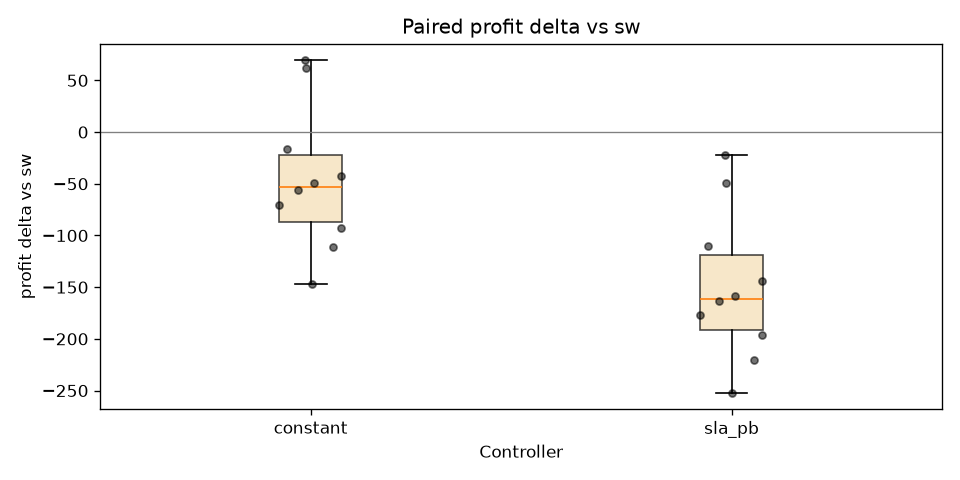

10_fill_rate_boxplot.png


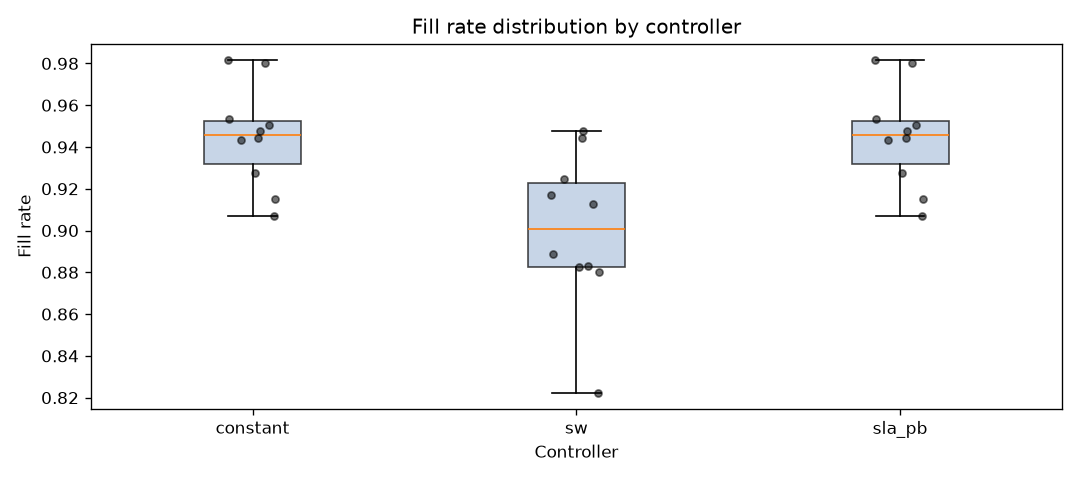

10_fill_rate_oracle_n45.png


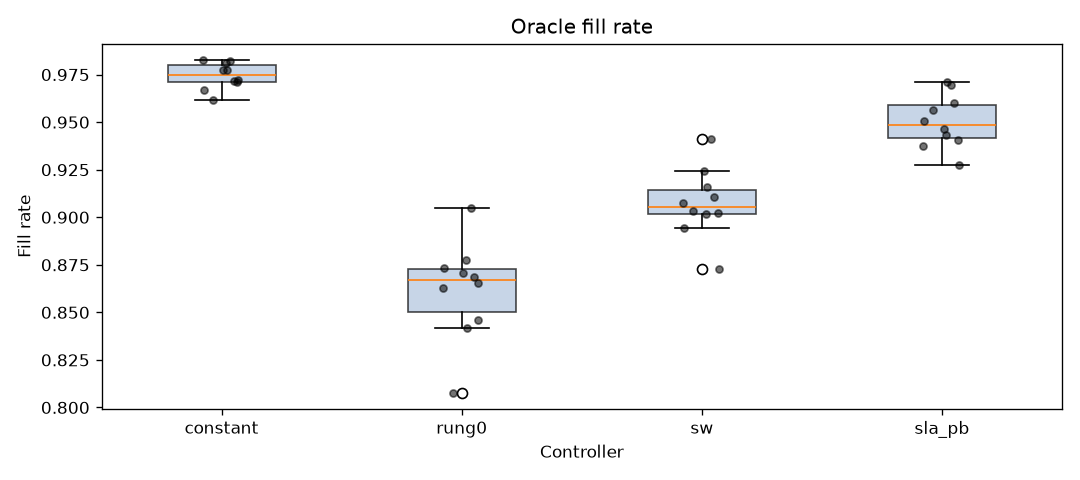

10b_fill_rate_filtered_n45.png


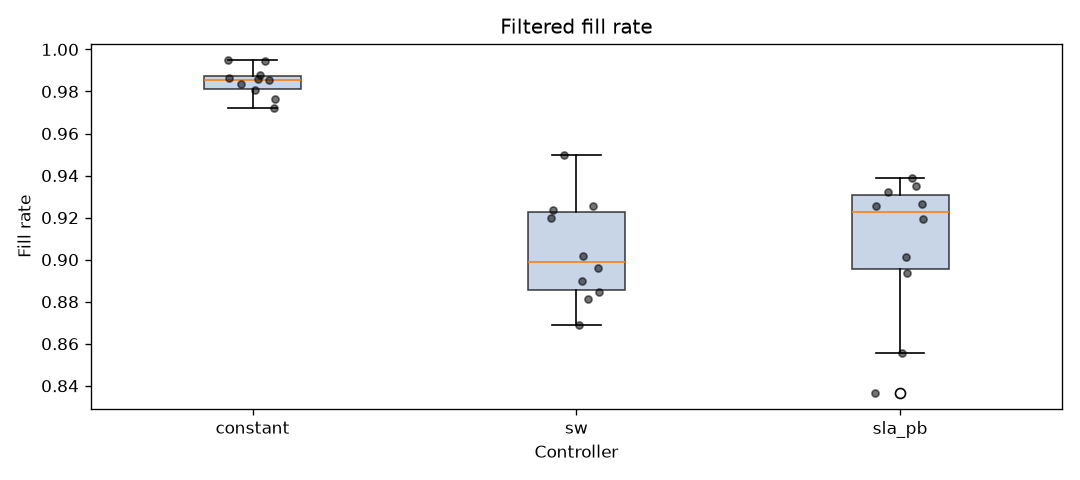

11_day_no_stockout_boxplot.png


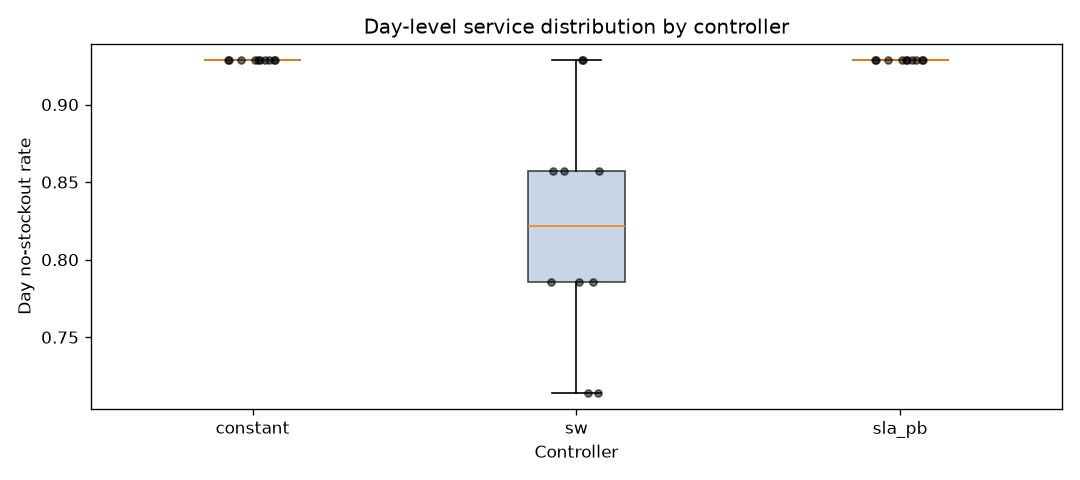

11_day_no_stockout_oracle_n45.png


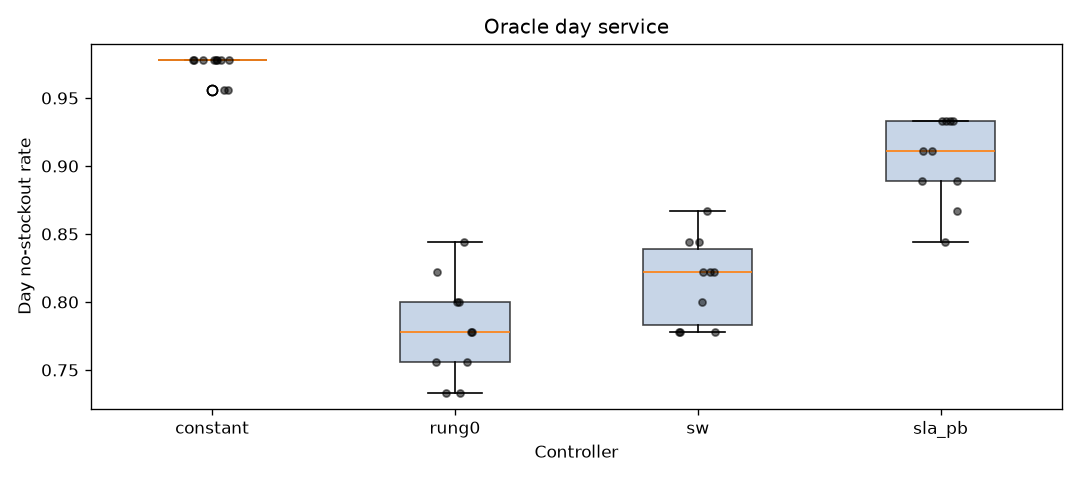

12_alpha_vs_fill_rate.png


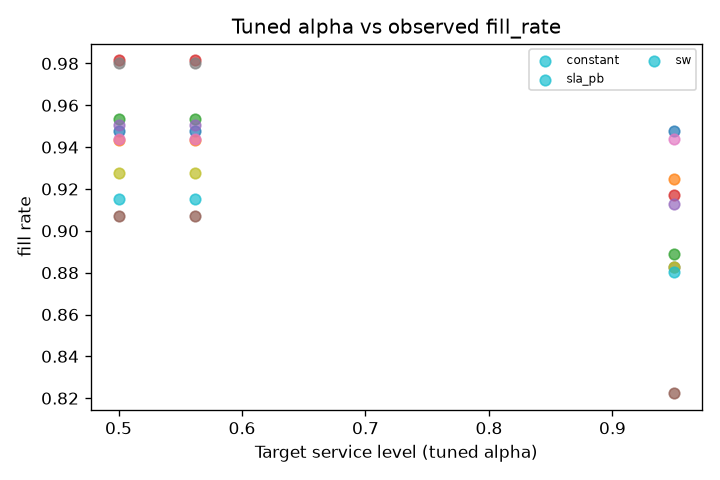

12_alpha_vs_fill_rate_n45.png


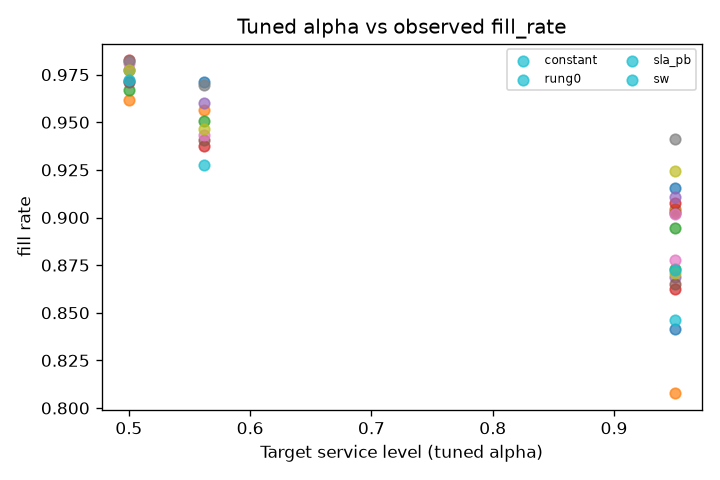

13_alpha_vs_day_no_stockout.png


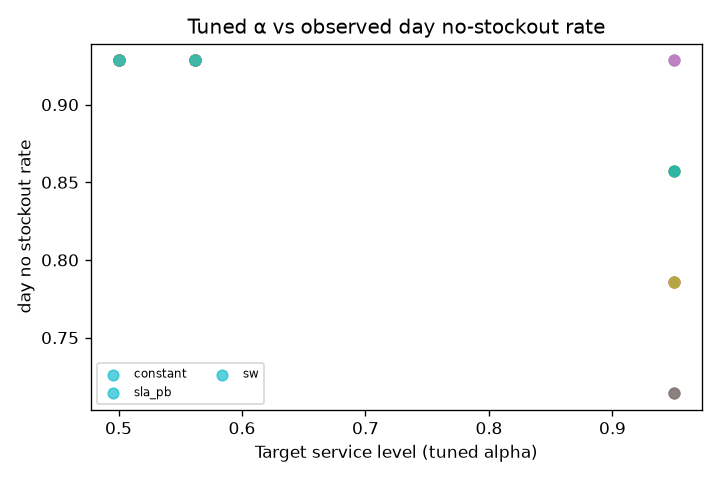

13_alpha_vs_day_no_stockout_n45.png


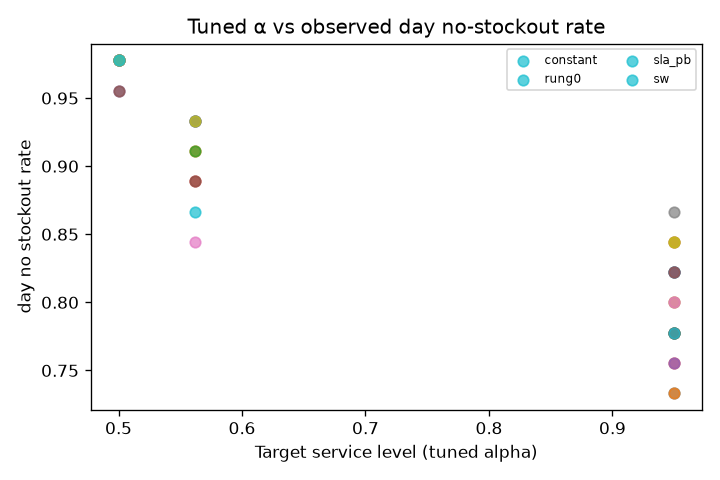

14_alpha_vs_observed_facets.png


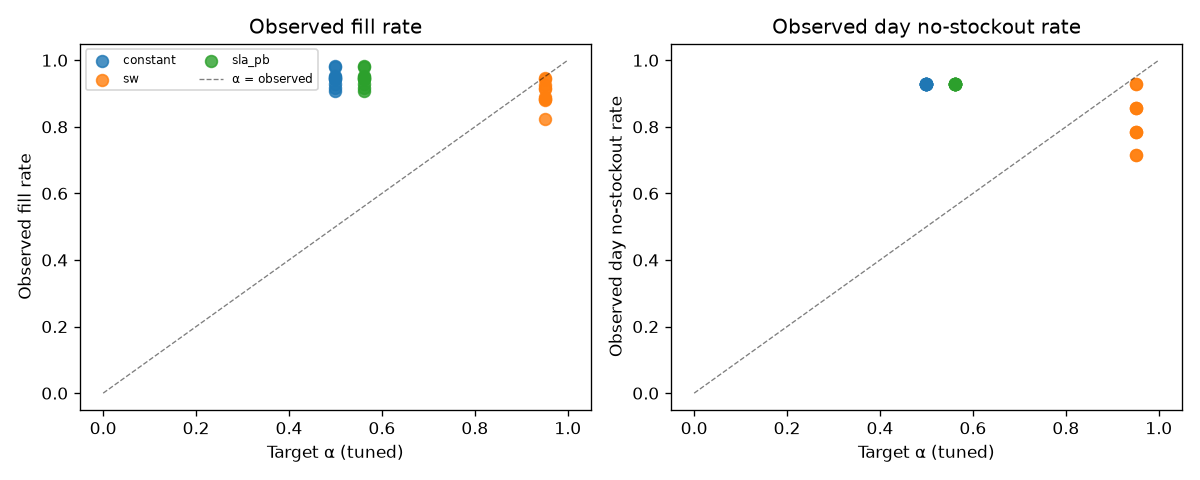

15_filtered_paired_delta_vs_sw.png


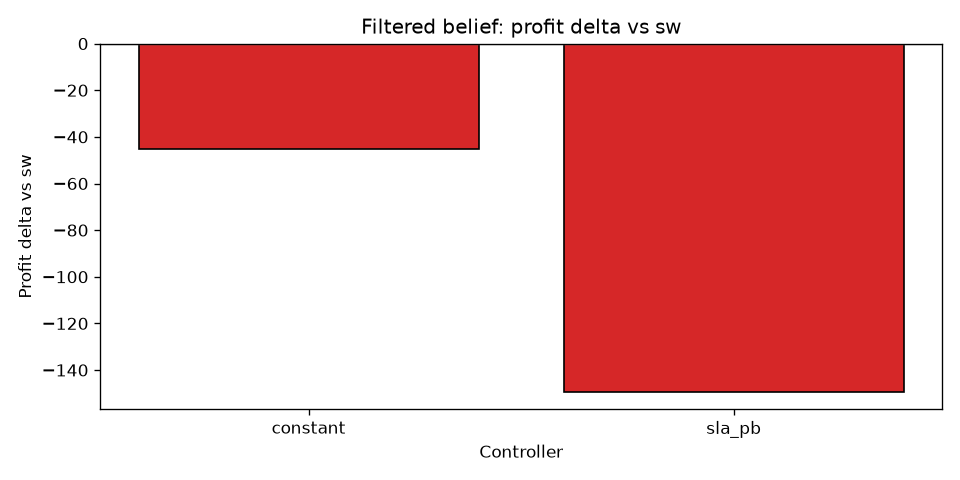

16_oracle_vs_filtered_profit.png


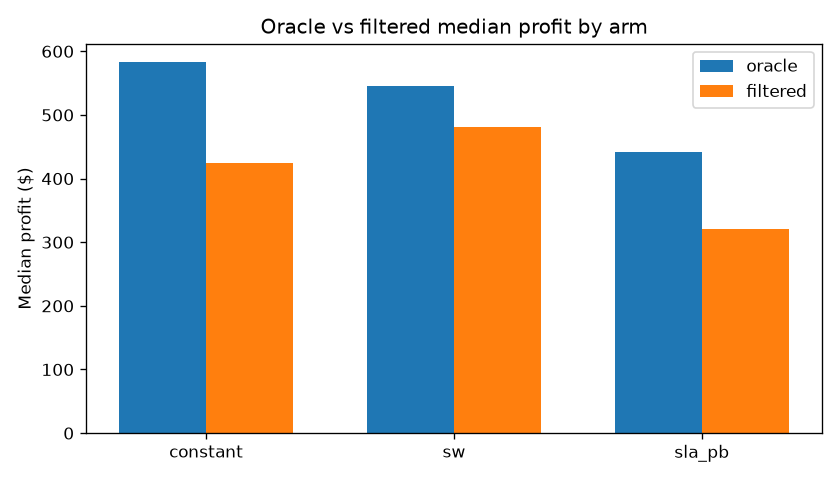

16_oracle_vs_filtered_profit_n45.png


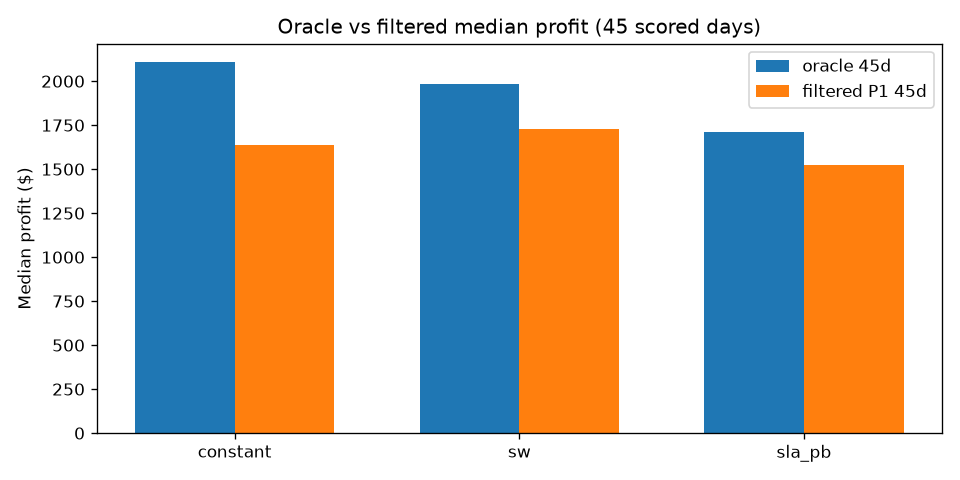

In [6]:
from IPython.display import Image, display

for fig_name in sorted(p.name for p in OUT_DIR.glob("*.png")):
    path = OUT_DIR / fig_name
    print(fig_name)
    display(Image(filename=str(path)))

## Oracle vs filtered + 45-day vs 14-day comparison


In [7]:
shared = list(SHARED_ARMS)
oracle_med_45 = oracle_df.groupby("arm_id")["profit"].median().reindex(shared)
filtered_med_45 = filtered_df.groupby("arm_id")["profit"].median().reindex(shared)
cross = pd.DataFrame({
    "oracle_n45": oracle_med_45,
    "filtered_n45": filtered_med_45,
    "delta_filtered_minus_oracle_n45": filtered_med_45 - oracle_med_45,
}).round(1)
display(cross)
cross.to_csv(OUT_DIR / "oracle_vs_filtered_profit_n45.csv")

oracle_rank_45 = oracle_med_45.sort_values(ascending=False).index.tolist()
filtered_rank_45 = filtered_med_45.sort_values(ascending=False).index.tolist()
print("Oracle 45d ranking:", oracle_rank_45)
print("Filtered 45d ranking:", filtered_rank_45)
print("Constant wins oracle 45d?", oracle_rank_45[0] == "constant")
print("Constant wins filtered 45d?", filtered_rank_45[0] == "constant")

arch_oracle = ARCHIVE_14D / "oracle_n14_rows.json"
arch_filtered = ARCHIVE_14D / "filtered_p0_n14_rows.json"
horizon_rows = []
if arch_oracle.is_file():
    o14 = pd.DataFrame(json.loads(arch_oracle.read_text()))
    o14_med = o14.groupby("arm_id")["profit"].median().reindex(shared)
    horizon_rows.append(("oracle_n14", o14_med))
if arch_filtered.is_file():
    f14 = pd.DataFrame(json.loads(arch_filtered.read_text()))
    f14_med = f14.groupby("arm_id")["profit"].median().reindex(shared)
    horizon_rows.append(("filtered_p0_n14", f14_med))
horizon_rows.append(("oracle_n45", oracle_med_45))
horizon_rows.append(("filtered_p1_n45", filtered_med_45))
horizon_cmp = pd.DataFrame({k: v for k, v in horizon_rows}).round(1)
display(horizon_cmp)
horizon_cmp.to_csv(OUT_DIR / "horizon_14_vs_45_profit.csv")

combined = pd.concat([oracle_df.assign(belief_world="oracle"), filtered_df.assign(belief_world="filtered")], ignore_index=True)
combined.to_csv(OUT_DIR / "filtered_vs_oracle_comparison_n45.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(shared))
w = 0.35
ax.bar(x - w / 2, oracle_med_45.values, w, label="oracle 45d")
ax.bar(x + w / 2, filtered_med_45.values, w, label="filtered P1 45d")
ax.set_xticks(x)
ax.set_xticklabels(shared)
ax.set_ylabel("Median profit ($)")
ax.set_title("Oracle vs filtered median profit (45 scored days)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "16_oracle_vs_filtered_profit_n45.png", dpi=120)
plt.close(fig)


,oracle_n45,filtered_n45,delta_filtered_minus_oracle_n45
arm_id,,,
constant,2108.2,1639.0,-469.2
sw,1984.8,1730.2,-254.5
sla_pb,2135.5,1695.8,-439.8


Oracle 45d ranking: ['sla_pb', 'constant', 'sw']
Filtered 45d ranking: ['sw', 'sla_pb', 'constant']
Constant wins oracle 45d? False
Constant wins filtered 45d? False


,oracle_n14,filtered_p0_n14,oracle_n45,filtered_p1_n45
arm_id,,,,
constant,583.0,424.2,2108.2,1639.0
sw,545.8,481.8,1984.8,1730.2
sla_pb,441.8,321.5,2135.5,1695.8
